# 05 — Карта страниц по OCR-якорям

Этот короткий ноутбук строит полную карту `страница → позиция в тексте` по результатам OCR-matching. Координаты совпадают с `audio_map` из 03c: это общая логическая шкала чтения.

Перед запуском один раз выполните обновлённый `05_ocr_text_matching.ipynb`: он пересчитает только TF-IDF-мэтчинг уже сохранённого OCR, без GPU и без повторного OCR. Затем запустите этот ноутбук сверху вниз.

Результат: `outputs/besy/page_map/<OCR_EXPERIMENT>/page_map.pkl`.

In [1]:
from __future__ import annotations

import json
import os
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path(os.environ.get(
    'SPARK_ROOT',
    '/home/wsl_user/my_projects/SPARK — Synchronized Print-Audio Reading Kit',
))
OCR_EXPERIMENT = 'experiment_03_lower_box_threshold'
OCR_MATCHES_PATH = PROJECT_ROOT / 'outputs/besy/ocr_matching' / OCR_EXPERIMENT / 'ocr_page_matches.json'
TEXT_DATA_PATH = PROJECT_ROOT / 'outputs/besy/run_01/normalized_text.pkl'
OUTPUT_DIR = PROJECT_ROOT / 'outputs/besy/page_map' / OCR_EXPERIMENT
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert OCR_MATCHES_PATH.is_file(), f'Нет {OCR_MATCHES_PATH}. Сначала выполните 05_ocr_text_matching.ipynb.'
assert TEXT_DATA_PATH.is_file(), f'Нет {TEXT_DATA_PATH}. Сначала выполните 01_text_normalization.ipynb.'


In [2]:
matches = json.loads(OCR_MATCHES_PATH.read_text(encoding='utf-8'))
anchors = sorted(
    (match for match in matches if match['confidence'] in {'reliable', 'plausible'}),
    key=lambda match: match['page_number'],
)
assert len(anchors) >= 2, 'Для интерполяции нужны хотя бы два надёжных или plausible-якоря.'
assert all(
    right['page_number'] > left['page_number'] and right['book_char_start'] > left['book_char_start']
    for left, right in zip(anchors, anchors[1:])
), 'Якоря должны возрастать и по странице, и по позиции текста.'

print(f'Якорей в карте: {len(anchors)}; страницы {anchors[0]["page_number"]}–{anchors[-1]["page_number"]}')
for anchor in anchors:
    print(f"стр. {anchor['page_number']:>3}: {anchor['book_char_start']:>8,} — {anchor['confidence']} — {anchor['section']}")


Якорей в карте: 14; страницы 10–699
стр.  10:    7,342 — reliable — Body 0 / Бесы / Часть первая / Глава первая
стр.  11:    9,824 — reliable — Body 0 / Бесы / Часть первая / Глава первая
стр.  96:  178,628 — reliable — Body 0 / Бесы / Часть первая / Глава третья
стр.  97:  180,767 — reliable — Body 0 / Бесы / Часть первая / Глава третья
стр. 182:  337,514 — reliable — Body 0 / Бесы / Часть первая / Глава пятая
стр. 183:  339,214 — reliable — Body 0 / Бесы / Часть первая / Глава пятая
стр. 356:  670,172 — reliable — Body 0 / Бесы / Часть вторая / Глава шестая
стр. 357:  671,472 — reliable — Body 0 / Бесы / Часть вторая / Глава шестая
стр. 528:  995,549 — reliable — Body 0 / Бесы / Часть третья / Глава четвертая
стр. 529:  997,515 — reliable — Body 0 / Бесы / Часть третья / Глава четвертая
стр. 614: 1,156,795 — reliable — Body 0 / Бесы / Часть третья / Глава седьмая
стр. 615: 1,157,652 — reliable — Body 0 / Бесы / Часть третья / Глава седьмая
стр. 698: 1,312,763 — reliable — Body 0 / Пр

In [3]:
with TEXT_DATA_PATH.open('rb') as file:
    text_data = pickle.load(file)

page_numbers = np.array([anchor['page_number'] for anchor in anchors])
anchor_positions = np.array([anchor['book_char_start'] for anchor in anchors])
all_pages = np.arange(page_numbers[0], page_numbers[-1] + 1)
positions = np.rint(np.interp(all_pages, page_numbers, anchor_positions)).astype(int)
anchor_by_page = {anchor['page_number']: anchor for anchor in anchors}

page_map = []
for index, (page_number, char_start) in enumerate(zip(all_pages, positions)):
    next_start = positions[index + 1] if index + 1 < len(positions) else len(text_data['normalized_text'])
    page_map.append({
        'page_number': int(page_number),
        'char_start': int(char_start),
        'char_end': int(max(char_start + 1, next_start)),
        'source': 'anchor' if int(page_number) in anchor_by_page else 'interpolated',
    })

payload = {
    'ocr_experiment': OCR_EXPERIMENT,
    'coordinate_system': 'logical reading positions from 01 matching_segments',
    'anchors': anchors,
    'page_map': page_map,
}
with (OUTPUT_DIR / 'page_map.pkl').open('wb') as file:
    pickle.dump(payload, file)
(OUTPUT_DIR / 'page_map.json').write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding='utf-8')

print(f'Сохранено страниц: {len(page_map)}')
print(f'Файлы: {OUTPUT_DIR / "page_map.pkl"} и {OUTPUT_DIR / "page_map.json"}')


Сохранено страниц: 690
Файлы: /home/wsl_user/my_projects/SPARK — Synchronized Print-Audio Reading Kit/outputs/besy/page_map/experiment_03_lower_box_threshold/page_map.pkl и /home/wsl_user/my_projects/SPARK — Synchronized Print-Audio Reading Kit/outputs/besy/page_map/experiment_03_lower_box_threshold/page_map.json


Leave-one-out (ошибка позиции, символов):
стр.  11: +490
стр.  96: -151
стр.  97: +291
стр. 182: +142
стр. 183: -212
стр. 356: +610
стр. 357: -592
стр. 528: -70
стр. 529: +91
стр. 614: +1,005
стр. 615: -1,000
стр. 698: +760


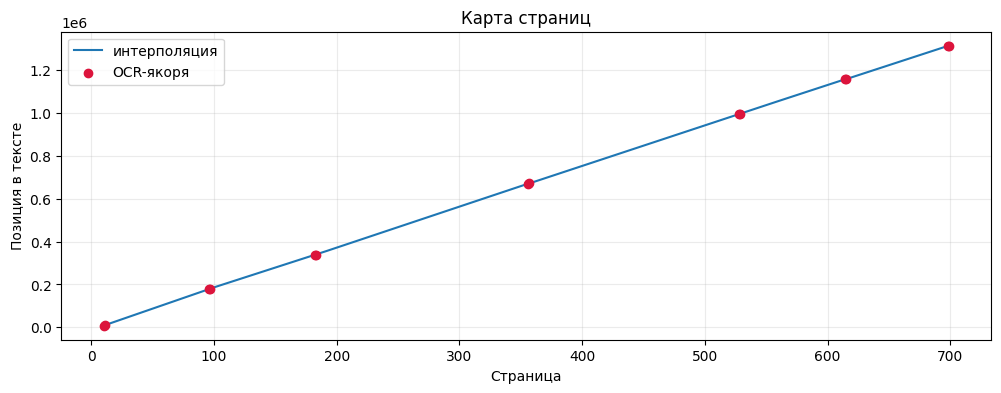

In [4]:
# Leave-one-out применим только к внутренним якорям: нужны соседи с обеих сторон.
errors = []
for left, current, right in zip(anchors, anchors[1:], anchors[2:]):
    predicted = np.interp(
        current['page_number'],
        [left['page_number'], right['page_number']],
        [left['book_char_start'], right['book_char_start']],
    )
    errors.append({
        'page': current['page_number'],
        'error_chars': int(round(current['book_char_start'] - predicted)),
    })

print('Leave-one-out (ошибка позиции, символов):')
for item in errors:
    print(f"стр. {item['page']:>3}: {item['error_chars']:+,}")

plt.figure(figsize=(12, 4))
plt.plot([item['page_number'] for item in page_map], [item['char_start'] for item in page_map], label='интерполяция')
plt.scatter(page_numbers, anchor_positions, color='crimson', zorder=3, label='OCR-якоря')
plt.xlabel('Страница')
plt.ylabel('Позиция в тексте')
plt.title('Карта страниц')
plt.grid(alpha=0.25)
plt.legend()
plt.show()
